In [121]:
from universe import *
from halo_fit import *
from weight import *
from pn_2d import *
from cmb import *
import numpy as np
from flat_map import FlatMap
import matplotlib.pyplot as plt
from PIL import Image
# number of pixels for the flat map
nX = 700 
nY = 700 
# map dimensions in degrees
sizeX = 10.
sizeY = 10.
# basic map object
baseMap = FlatMap(nX=nX, nY=nY, sizeX=sizeX*np.pi/180., sizeY=sizeY*np.pi/180.)
# multipoles to include in the lensing reconstruction
lMin = 5.; lMax = 3500.#4.e3 #30, 3.5e3
# ell bins for power spectra
nBins = 21  # number of bins
lRange = (1., 2.*lMax)  # range for power spectra
u = UnivPlanck15()
halofit = Halofit(u, save=False)
w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False)
kCmbFourier = baseMap.genGRF(lambda x: p2d_cmblens.fPinterp(x)*20, test=False)
kCmb = baseMap.inverseFourier(kCmbFourier)
# load my face
myface = Image.open('/home/noah/Pictures/Screenshots/me_and_cat.png')
myface = np.array(myface)[:nX,:nY,:]
# lens my face
myface_lensed = myface.copy()
for i in range(4):
    myface_lensed[:,:,i] = baseMap.doLensing(myface[:,:,i],kCmbFourier)

In [38]:
my_lensed_face = np.array(Image.open('/home/noah/Downloads/my_lensed_face_gray.jpg'))
kCmb           = np.genfromtxt('important_kCmb.txt')

In [40]:
kCmbFourier = baseMap.fourier(kCmb)
kCmbFourier_filt = baseMap.filterFourierIsotropic(lambda l: np.exp(-(l/200)**6),kCmbFourier)
kCmb_filt = baseMap.inverseFourier(kCmbFourier_filt)

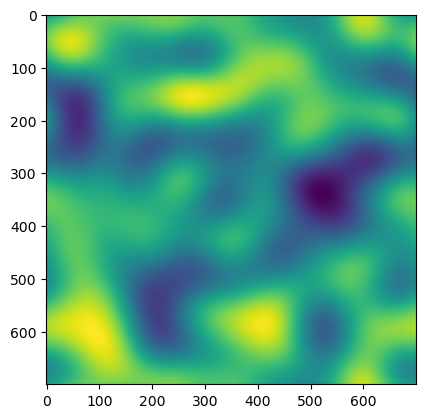

In [41]:
plt.imshow(kCmb_filt)

In [116]:
def make_contour(x,val=0.6,dx = 0.01):
    tmp = np.ones_like(kCmb_filt)
    tmp[np.where((kCmb_filt>x) & (kCmb_filt<x+dx))] = val
    return tmp

xx = [-0.2,-0.1,0,0.1]
vals = [0.5,0.6,0.7,0.8]
contours = [make_contour(xx[i],vals[i]) for i in range(4)]

In [117]:
cool_face = (my_lensed_face*np.prod(contours,axis=0))[5:695,5:695]

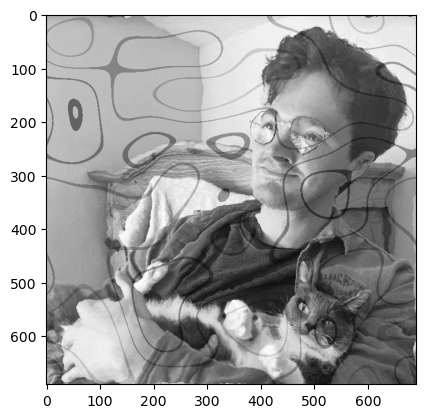

In [124]:
plt.imshow(cool_face,cmap='Greys_r')

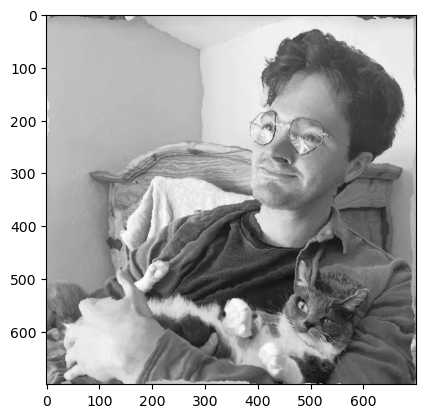

In [123]:
plt.imshow(my_lensed_face,cmap='Greys_r')

In [128]:
Image.fromarray(cool_face).convert('L').save('/home/noah/Downloads/my_lensed_face_gray_wcontour.jpg')